In [16]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt
import networkx as nx
import random

from tqdm import tqdm
pd.set_option('display.max_columns', 5000)

In [17]:
def format_ml(df_crime, df_lamps):
    """
    Transforms a wide-format crime dataset into a long format with lag features for ML.
    Now correctly merges static street lighting data and prevents double-smoothing.
    """
    # Merge static lighting data onto the crime network
    df = pd.merge(df_crime, df_lamps[['edge_id', 'lamp_count', 'lamp_per_km', 'is_lit']], on='edge_id', how='left')
    
    # 1. Isolate static features (Added osmid, is_lit, and lamp_per_km)
    static_features = [
        'edge_id', 'osmid', 'u', 'u_lat', 'u_lng', 'v', 'v_lat', 'v_lng', 
        'key', 'name', 'highway', 'length', 'is_lit', 'lamp_per_km'
    ]
    df_static = df[static_features].copy()

    # 2. Isolating time series
    # The regex will now automatically pick up the new _netkde_YYYY_MM columns
    time_cols = [col for col in df.columns if pd.Series(col).str.contains(r'\d{4}_\d{2}$').any()]
    df_time = df[['edge_id'] + time_cols].copy()

    # 3. Condensing all time columns into 'metric' and 'value'
    df_melted = df_time.melt(id_vars='edge_id', var_name='metric_month', value_name='value')

    # 4. Split the melted column into a 'metric' and a 'year_month'
    extract_regex = r'^(?P<metric>.*)_(?P<year_month>\d{4}_\d{2})$'
    df_melted[['metric', 'year_month']] = df_melted['metric_month'].str.extract(extract_regex)
    df_melted = df_melted.drop(columns=['metric_month'])

    # 5. Pivot: Push the metrics back into their own distinct columns
    df_long = df_melted.pivot(
        index=['edge_id', 'year_month'], 
        columns='metric', 
        values='value'
    ).reset_index()

    # 6. Sort chronologically
    df_long = df_long.sort_values(by=['edge_id', 'year_month'])

    # 7. Engineer Lag Features (2, 3, and 4 months to account for API delay)
    lags = [2, 3, 4]
    metrics_to_lag = ['crime_perceived_risk_sum_netkde', 'stop_search_count_netkde']

    for metric in metrics_to_lag:
        for lag in lags:
            df_long[f'{metric}_lag_{lag}'] = df_long.groupby('edge_id')[metric].shift(lag)

    # 8. Drop rows with NaNs caused by the shift
    df_long = df_long.dropna(subset=[f'{metric}_lag_{lag}' for metric in metrics_to_lag for lag in lags]).reset_index(drop=True)

    # 9. Merge the static street metadata back in
    final_df = pd.merge(df_long, df_static, on='edge_id', how='left')

    # 10. Rename current month metrics to 'target'
    final_df = final_df.rename(columns={
        'crime_perceived_risk_sum_netkde': 'target_perceived_risk',
        'stop_search_count_netkde': 'target_stop_search'
    })
    
    # 11. NetKDE double-smoothing logic removed entirely.
    
    return final_df

In [18]:
def train_crime_model(ml_ready_df):
    """
    Trains the XGBoost ML model to predict NetKDE Perceived Risk
    """
    # 1. Define the chronological cutoff
    cutoff_month = '2026_03'
    
    # 2. Split into Train (Past) and Test (Future)
    train_df = ml_ready_df[ml_ready_df['year_month'] < cutoff_month].copy()
    test_df = ml_ready_df[ml_ready_df['year_month'] >= cutoff_month].copy()
    
    print(f"Training on {len(train_df)} records (Before {cutoff_month})")
    print(f"Testing on {len(test_df)} records ({cutoff_month} onwards)")

    # 3. Define the Target (y)
    target_col = 'target_perceived_risk'
    
    # 4. Define Features (X)
    # Dropping osmid alongside identifiers to prevent ML from learning raw IDs
    cols_to_drop = [
        'edge_id', 'osmid', 'year_month', 'name', 'u', 'v', 'key',
        'target_perceived_risk', 'target_stop_search',
        'crime_count_netkde', 'crime_severity_sum_netkde', 
        'crime_perceived_risk_sum' , 'crime_severity_sum', 'crime_count', 'stop_search_count'
    ]
    
    train_df['highway'] = train_df['highway'].astype('category')
    test_df['highway'] = test_df['highway'].astype('category')
    
    X_train = train_df.drop(columns=cols_to_drop, errors='ignore')
    y_train = train_df[target_col]
    
    X_test = test_df.drop(columns=cols_to_drop, errors='ignore')
    y_test = test_df[target_col]

    # 5. Initialize XGBoost Regressor
    # Objective changed to reg:squarederror because the target is a continuous float
    model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        enable_categorical=True,
        random_state=42,
        early_stopping_rounds=50,
        objective='reg:tweedie'
    )

    # 6. Train the model
    print("Training XGBoost...")
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=50
    )

    # 7. Evaluate the predictions
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    print(f"\nMean Absolute Error (MAE): {mae:.2f} perceived risk score per street")
    
    return model, X_train.columns

In [19]:
def feature_importance(model, X_train):
    """
    Extracts feature importance and displays in a bar chart.
    """
    # 1. Visual Plot: Using XGBoost's built-in plotter
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # We use importance_type='gain' because it measures predictive power
    xgb.plot_importance(
        model, 
        importance_type='gain', 
        max_num_features=15, # Only show the top 15 features
        ax=ax, 
        height=0.5,
        color='steelblue'
    )
    plt.title("Top 15 Most Predictive Features (by Information Gain)")
    plt.show()

    # 2. Raw Data: Extracting into a Pandas DataFrame
    importance_dict = model.get_booster().get_score(importance_type='gain')
    
    importance_df = pd.DataFrame({
        'Feature': list(importance_dict.keys()),
        'Gain': list(importance_dict.values())
    })
    
    # Sort from most to least important
    importance_df = importance_df.sort_values(by='Gain', ascending=False).reset_index(drop=True)
    
    print("\nFeature Importance Rankings:")
    print(importance_df.head(15))
    
    return importance_df

In [20]:
def predict_and_map_to_nodes(ml_ready_df, model, feature_columns, month_t_minus_2, month_t_minus_3, month_t_minus_4):
    """
    Maps historical targets directly into future lags, predicts danger, and prepares OSM node/edge costs.
    """
    if isinstance(feature_columns, pd.DataFrame):
        feature_columns = feature_columns.columns.tolist()
    elif hasattr(feature_columns, 'tolist'):
        feature_columns = feature_columns.tolist()
    
    # 1. Isolate the base metadata from the most recent month to serve as our template
    future_data = ml_ready_df[ml_ready_df['year_month'] == month_t_minus_2].copy()
    
    # 2. Extract historical targets to use as future lags
    data_t2 = ml_ready_df[ml_ready_df['year_month'] == month_t_minus_2].set_index('edge_id')
    data_t3 = ml_ready_df[ml_ready_df['year_month'] == month_t_minus_3].set_index('edge_id')
    data_t4 = ml_ready_df[ml_ready_df['year_month'] == month_t_minus_4].set_index('edge_id')
    
    # 3. Map the true historical values directly into the required lags
    future_data['crime_perceived_risk_sum_netkde_lag_2'] = future_data['edge_id'].map(data_t2['target_perceived_risk']).fillna(0)
    future_data['crime_perceived_risk_sum_netkde_lag_3'] = future_data['edge_id'].map(data_t3['target_perceived_risk']).fillna(0)
    future_data['crime_perceived_risk_sum_netkde_lag_4'] = future_data['edge_id'].map(data_t4['target_perceived_risk']).fillna(0)
    
    future_data['stop_search_count_netkde_lag_2'] = future_data['edge_id'].map(data_t2['target_stop_search']).fillna(0)
    future_data['stop_search_count_netkde_lag_3'] = future_data['edge_id'].map(data_t3['target_stop_search']).fillna(0)
    future_data['stop_search_count_netkde_lag_4'] = future_data['edge_id'].map(data_t4['target_stop_search']).fillna(0)
    
    if 'highway' in future_data.columns:
        future_data['highway'] = future_data['highway'].astype('category')
    
    X_future = future_data[feature_columns]

    # 4. Generate Predictions
    print("Predicting future safety scores...")
    future_data['predicted_risk'] = model.predict(X_future)
    future_data['predicted_risk'] = future_data['predicted_risk'].clip(lower=0)

    # 5. Calculate "Safety Cost" (1-10 Scale)
    future_data['log_risk'] = np.log1p(future_data['predicted_risk'])
    max_risk = future_data['log_risk'].max()
    min_risk = future_data['log_risk'].min()
    
    if max_risk == min_risk:
        print("Warning: The model predicted flat values. Cost is flat.")
        future_data['safety_tag_value'] = 1.0
    else:
        # Scale to exactly 1-10 (multiply by 9, add 1)
        future_data['safety_tag_value'] = 1 + ((future_data['log_risk'] - min_risk) / (max_risk - min_risk) * 9)

    # 6. Map Edge Costs onto OSM Nodes
    u_nodes = future_data[['u', 'u_lat', 'u_lng', 'safety_tag_value']].rename(
        columns={'u': 'node_id', 'u_lat': 'lat', 'u_lng': 'lng', 'safety_tag_value': 'cost'}
    )
    v_nodes = future_data[['v', 'v_lat', 'v_lng', 'safety_tag_value']].rename(
        columns={'v': 'node_id', 'v_lat': 'lat', 'v_lng': 'lng', 'safety_tag_value': 'cost'}
    )
    
    all_nodes = pd.concat([u_nodes, v_nodes])
    node_safety_df = all_nodes.groupby('node_id').agg(
        node_safety_cost=('cost', 'mean'),
        lat=('lat', 'first'),
        lng=('lng', 'first')
    ).reset_index()

    node_safety_df = node_safety_df.sort_values(by='node_safety_cost', ascending=False).reset_index(drop=True)
    return future_data, node_safety_df


In [21]:
def osm_tag_mapping(future_edges_df):
    """
    Creates a clean mapping of OSM Way IDs to Safety Costs, lighting values.
    """
    df = future_edges_df.copy()
    
    # We round the safety cost to an integer (1-10) to make the Valhalla Lua costing easier
    df['safety_tag_value'] = df['safety_tag_value'].round().astype(int)
    
    # Isolate just the OSM ID and the new Tag Value
    osm_tags = df[['osmid', 'safety_tag_value', 'is_lit']].drop_duplicates()
    
    osm_tags.to_csv('osm_safety_tags.csv', index=False)
    print("Saved OSM Tag mapping. Use this to tag your .osm.pbf file.")

In [22]:
def evaluate_routing_performance(edges_df, num_simulations=1000, dark_penalty=5.0, random_seed=42):
    """
    Evaluates ML safety routing for both Daytime and Nighttime scenarios simultaneously.
    Includes seeded randomness for exact reproducibility.
    """
    print(f"Building Day and Night evaluation graphs (Seed: {random_seed})...")
    
    # 1. Seed the randomness to guarantee reproducible O-D pairs
    random.seed(random_seed)
    
    # 2. Build the Graph
    G = nx.Graph()
    for _, row in edges_df.iterrows():
        
        # Daytime Weight: Pure ML historical risk
        day_weight = row['length'] * row['safety_tag_value']
        
        # Nighttime Weight: ML historical risk * dynamic lighting penalty
        lighting_multiplier = dark_penalty if row['is_lit'] == 0 else 1.0
        night_weight = row['length'] * row['safety_tag_value'] * lighting_multiplier
        
        G.add_edge(
            row['u'], 
            row['v'], 
            length=row['length'], 
            day_routing_weight=day_weight,
            night_routing_weight=night_weight,
            true_risk=row['target_perceived_risk'] * row['length'], 
            is_lit=row['is_lit'] 
        )

    nodes = list(G.nodes())
    results = []
    
    print(f"Running {num_simulations} simulated O-D pairs...")
    
    for _ in tqdm(range(num_simulations), desc="Simulating Routes"):
        origin, destination = random.sample(nodes, 2)
        
        try:
            # Standard Routing (Baseline)
            shortest_path = nx.shortest_path(G, origin, destination, weight='length')
            # Daytime ML Routing
            day_path = nx.shortest_path(G, origin, destination, weight='day_routing_weight')
            # Nighttime ML Routing
            night_path = nx.shortest_path(G, origin, destination, weight='night_routing_weight')
            
            # Helper function to extract metrics
            def calculate_path_metrics(path):
                t_dist, t_risk, t_unlit = 0.0, 0.0, 0.0
                for i in range(len(path) - 1):
                    u, v = path[i], path[i+1]
                    edge_data = G[u][v]
                    t_dist += edge_data['length']
                    t_risk += edge_data['true_risk']
                    if edge_data['is_lit'] == 0:
                        t_unlit += edge_data['length']
                return t_dist, t_risk, t_unlit

            dist_short, risk_short, unlit_short = calculate_path_metrics(shortest_path)
            dist_day, risk_day, unlit_day = calculate_path_metrics(day_path)
            dist_night, risk_night, unlit_night = calculate_path_metrics(night_path)
            
            if dist_short == 0:
                continue 
                
            # --- DAYTIME METRICS ---
            day_pct_risk_red = ((risk_short - risk_day) / risk_short) * 100 if risk_short > 0 else 0
            day_pct_dist_inc = ((dist_day - dist_short) / dist_short) * 100
            day_unlit_avoided = unlit_short - unlit_day
            day_pct_unlit_red = (day_unlit_avoided / unlit_short) * 100 if unlit_short > 0 else 0
            
            # --- NIGHTTIME METRICS ---
            night_pct_risk_red = ((risk_short - risk_night) / risk_short) * 100 if risk_short > 0 else 0
            night_pct_dist_inc = ((dist_night - dist_short) / dist_short) * 100
            night_unlit_avoided = unlit_short - unlit_night
            night_pct_unlit_red = (night_unlit_avoided / unlit_short) * 100 if unlit_short > 0 else 0
            
            results.append({
                'dist_shortest': dist_short,
                'dist_day': dist_day,
                'dist_night': dist_night,
                'unlit_shortest': unlit_short,
                'day_dist_increase': day_pct_dist_inc,
                'day_risk_reduction': day_pct_risk_red,
                'day_unlit_avoided': day_unlit_avoided,
                'day_pct_unlit_reduction': day_pct_unlit_red,
                'night_dist_increase': night_pct_dist_inc,
                'night_risk_reduction': night_pct_risk_red,
                'night_unlit_avoided': night_unlit_avoided,
                'night_pct_unlit_reduction': night_pct_unlit_red
            })
            
        except nx.NetworkXNoPath:
            continue

    results_df = pd.DataFrame(results)
    
    # Calculate how many routes actually diverged from the shortest path
    divergent_routes = results_df[
        (results_df['dist_day'] != results_df['dist_shortest']) | 
        (results_df['dist_night'] != results_df['dist_shortest'])
    ]
    
    print("\n=== ROUTING EVALUATION RESULTS ===")
    print(f"Total valid simulated O-D pairs: {len(results_df)}")
    print(f"Total divergent routes (algorithm chose a different path): {len(divergent_routes)}")
    
    print("\n--- BASELINE (Shortest Path) ---")
    print(f"Average Distance: {results_df['dist_shortest'].mean():.1f}m")
    
    print("\n--- DAYTIME Routing ---")
    print(f"Average Distance (Safest Path): {results_df['dist_day'].mean():.1f}m")
    print(f"Average Distance Increase: {results_df['day_dist_increase'].mean():.2f}%")
    print(f"Average Crime Risk Reduction: {results_df['day_risk_reduction'].mean():.2f}%")
    print(f"Average Unlit Meters Avoided: {results_df['day_unlit_avoided'].mean():.1f}m")
    print(f"Percentage Reduction in Darkness Exposure: {results_df['day_pct_unlit_reduction'].mean():.2f}%")

    print("\n--- NIGHTTIME Routing ---")
    print(f"Average Distance (Safest Path): {results_df['dist_night'].mean():.1f}m")
    print(f"Average Distance Increase: {results_df['night_dist_increase'].mean():.2f}%")
    print(f"Average Crime Risk Reduction: {results_df['night_risk_reduction'].mean():.2f}%")
    print(f"Average Unlit Meters Avoided: {results_df['night_unlit_avoided'].mean():.1f}m")
    print(f"Percentage Reduction in Darkness Exposure: {results_df['night_pct_unlit_reduction'].mean():.2f}%")
    
    return results_df

# Execution
# simulation_results = evaluate_day_vs_night_routing(future_edges, num_simulations=1000, random_seed=42)

In [23]:
df_crime = pd.read_csv('data_out/edge_features.csv')
df_lamps = pd.read_csv('data_out/edge_lamp_features.csv')

df_ml = format_ml(df_crime, df_lamps)

In [24]:
df_crime.head()

,edge_id,osmid,u,u_lat,u_lng,v,v_lat,v_lng,key,name,highway,length,crime_count,crime_severity_sum,crime_perceived_risk_sum,stop_search_count,crime_count_2023_06,crime_count_2023_07,crime_count_2023_08,crime_count_2023_09,crime_count_2023_10,crime_count_2023_11,crime_count_2023_12,crime_count_2024_01,crime_count_2024_02,crime_count_2024_03,crime_count_2024_04,crime_count_2024_05,crime_count_2024_06,crime_count_2024_07,crime_count_2024_08,crime_count_2024_09,crime_count_2024_10,crime_count_2024_11,crime_count_2024_12,crime_count_2025_01,crime_count_2025_02,crime_count_2025_03,crime_count_2025_04,crime_count_2025_05,crime_count_2025_06,crime_count_2025_07,crime_count_2025_08,crime_count_2025_09,crime_count_2025_10,crime_count_2025_11,crime_count_2025_12,crime_count_2026_01,crime_count_2026_02,crime_count_2026_03,crime_count_2026_04,crime_count_2026_05,crime_severity_sum_2023_06,crime_severity_sum_2023_07,crime_severity_sum_2023_08,crime_severity_sum_2023_09,crime_severity_sum_2023_10,crime_severity_sum_2023_11,crime_severity_sum_2023_12,crime_severity_sum_2024_01,crime_severity_sum_2024_02,crime_severity_sum_2024_03,crime_severity_sum_2024_04,crime_severity_sum_2024_05,crime_severity_sum_2024_06,crime_severity_sum_2024_07,crime_severity_sum_2024_08,crime_severity_sum_2024_09,crime_severity_sum_2024_10,crime_severity_sum_2024_11,crime_severity_sum_2024_12,crime_severity_sum_2025_01,crime_severity_sum_2025_02,crime_severity_sum_2025_03,crime_severity_sum_2025_04,crime_severity_sum_2025_05,crime_severity_sum_2025_06,crime_severity_sum_2025_07,crime_severity_sum_2025_08,crime_severity_sum_2025_09,crime_severity_sum_2025_10,crime_severity_sum_2025_11,crime_severity_sum_2025_12,crime_severity_sum_2026_01,crime_severity_sum_2026_02,crime_severity_sum_2026_03,crime_severity_sum_2026_04,crime_severity_sum_2026_05,crime_perceived_risk_sum_2023_06,crime_perceived_risk_sum_2023_07,crime_perceived_risk_sum_2023_08,crime_perceived_risk_sum_2023_09,crime_perceived_risk_sum_2023_10,crime_perceived_risk_sum_2023_11,crime_perceived_risk_sum_2023_12,crime_perceived_risk_sum_2024_01,crime_perceived_risk_sum_2024_02,crime_perceived_risk_sum_2024_03,crime_perceived_risk_sum_2024_04,crime_perceived_risk_sum_2024_05,crime_perceived_risk_sum_2024_06,crime_perceived_risk_sum_2024_07,crime_perceived_risk_sum_2024_08,crime_perceived_risk_sum_2024_09,crime_perceived_risk_sum_2024_10,crime_perceived_risk_sum_2024_11,crime_perceived_risk_sum_2024_12,crime_perceived_risk_sum_2025_01,crime_perceived_risk_sum_2025_02,crime_perceived_risk_sum_2025_03,crime_perceived_risk_sum_2025_04,crime_perceived_risk_sum_2025_05,crime_perceived_risk_sum_2025_06,crime_perceived_risk_sum_2025_07,crime_perceived_risk_sum_2025_08,crime_perceived_risk_sum_2025_09,crime_perceived_risk_sum_2025_10,crime_perceived_risk_sum_2025_11,crime_perceived_risk_sum_2025_12,crime_perceived_risk_sum_2026_01,crime_perceived_risk_sum_2026_02,crime_perceived_risk_sum_2026_03,crime_perceived_risk_sum_2026_04,crime_perceived_risk_sum_2026_05,stop_search_count_2023_06,stop_search_count_2023_07,stop_search_count_2023_08,stop_search_count_2023_09,stop_search_count_2023_10,stop_search_count_2023_11,stop_search_count_2023_12,stop_search_count_2024_01,stop_search_count_2024_02,stop_search_count_2024_03,stop_search_count_2024_04,stop_search_count_2024_05,stop_search_count_2024_06,stop_search_count_2024_07,stop_search_count_2024_08,stop_search_count_2024_09,stop_search_count_2024_10,stop_search_count_2024_11,stop_search_count_2024_12,stop_search_count_2025_01,stop_search_count_2025_02,stop_search_count_2025_03,stop_search_count_2025_04,stop_search_count_2025_05,stop_search_count_2025_06,stop_search_count_2025_07,stop_search_count_2025_08,stop_search_count_2025_09,stop_search_count_2025_10,stop_search_count_2025_11,stop_search_count_2025_12,stop_search_count_2026_01,stop_search_count_2026_02,stop_search_count_2026_03,stop_search_count_2026_04,stop_search_count_2026_05,crime_per_km,crime_severity_per_km,crime_av

In [25]:
model, X_train = train_crime_model(df_ml)

Training on 1030544 records (Before 2026_03)
Testing on 106608 records (2026_03 onwards)
Training XGBoost...
[0]	validation_0-tweedie-nloglik@1.5:9.78306	validation_1-tweedie-nloglik@1.5:9.43910
[50]	validation_0-tweedie-nloglik@1.5:5.55446	validation_1-tweedie-nloglik@1.5:5.48218
[100]	validation_0-tweedie-nloglik@1.5:5.38279	validation_1-tweedie-nloglik@1.5:5.37440
[142]	validation_0-tweedie-nloglik@1.5:5.36790	validation_1-tweedie-nloglik@1.5:5.37231

Mean Absolute Error (MAE): 2.44 perceived risk score per street


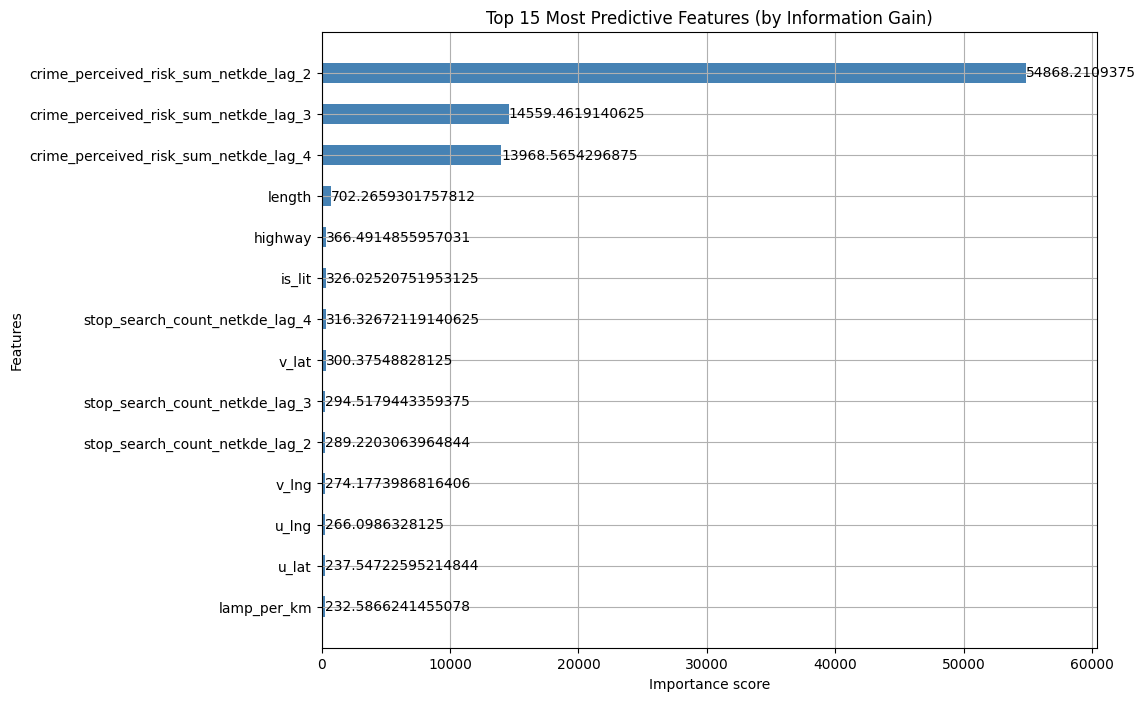


Feature Importance Rankings:
                                  Feature          Gain
0   crime_perceived_risk_sum_netkde_lag_2  54868.210938
1   crime_perceived_risk_sum_netkde_lag_3  14559.461914
2   crime_perceived_risk_sum_netkde_lag_4  13968.565430
3                                  length    702.265930
4                                 highway    366.491486
5                                  is_lit    326.025208
6          stop_search_count_netkde_lag_4    316.326721
7                                   v_lat    300.375488
8          stop_search_count_netkde_lag_3    294.517944
9          stop_search_count_netkde_lag_2    289.220306
10                                  v_lng    274.177399
11                                  u_lng    266.098633
12                                  u_lat    237.547226
13                            lamp_per_km    232.586624


,Feature,Gain
0,crime_perceived_risk_sum_netkde_lag_2,54868.210938
1,crime_perceived_risk_sum_netkde_lag_3,14559.461914
2,crime_perceived_risk_sum_netkde_lag_4,13968.565430
3,length,702.265930
4,highway,366.491486
5,is_lit,326.025208
6,stop_search_count_netkde_lag_4,316.326721
7,v_lat,300.375488
8,stop_search_count_netkde_lag_3,294.517944
9,stop_search_count_netkde_lag_2,289.220306


In [26]:
feature_importance(model, X_train)

In [27]:
future_edges, future_node = predict_and_map_to_nodes(
    df_ml, 
    model, 
    X_train, 
    month_t_minus_2='2026_05', 
    month_t_minus_3='2026_04', 
    month_t_minus_4='2026_03'
)

Predicting future safety scores...


In [28]:
osm_tag_mapping(future_edges)

Saved OSM Tag mapping. Use this to tag your .osm.pbf file.


In [29]:
simulation_results = evaluate_routing_performance(future_edges)

simulation_results.head()

Building Day and Night evaluation graphs (Seed: 42)...
Running 1000 simulated O-D pairs...


Simulating Routes: 100%|██████████| 1000/1000 [00:26<00:00, 37.52it/s]


=== ROUTING EVALUATION RESULTS ===
Total valid simulated O-D pairs: 1000
Total divergent routes (algorithm chose a different path): 985

--- BASELINE (Shortest Path) ---
Average Distance: 3511.4m

--- DAYTIME Routing ---
Average Distance (Safest Path): 3778.3m
Average Distance Increase: 7.98%
Average Crime Risk Reduction: 80.99%
Average Unlit Meters Avoided: -91.1m
Percentage Reduction in Darkness Exposure: -11.90%

--- NIGHTTIME Routing ---
Average Distance (Safest Path): 4346.8m
Average Distance Increase: 23.56%
Average Crime Risk Reduction: 65.74%
Average Unlit Meters Avoided: 910.0m
Percentage Reduction in Darkness Exposure: 52.76%


,dist_shortest,dist_day,dist_night,unlit_shortest,day_dist_increase,day_risk_reduction,day_unlit_avoided,day_pct_unlit_reduction,night_dist_increase,night_risk_reduction,night_unlit_avoided,night_pct_unlit_reduction
0,375.311516,434.026280,512.265521,375.311516,15.644275,97.238944,-58.714765,-15.644275,36.490755,20.586266,171.657974,45.737465
1,2334.136513,2540.327749,3183.959304,1001.915082,8.833727,83.931795,-7.138434,-0.712479,36.408444,87.027363,545.193176,54.415108
2,6261.910855,6994.491777,8474.765413,2569.124510,11.699000,96.361128,-795.332397,-30.957332,35.338327,90.884861,1438.517341,55.992512
3,1710.425050,1801.262876,1943.661474,499.949240,5.310833,93.661097,-79.350359,-15.871683,13.636167,52.628988,386.665423,77.340936
4,4214.738947,4417.368175,4965.005320,2109.252718,4.807634,89.264567,360.631528,17.097597,17.801016,68.031743,1224.968820,58.075963
